In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as m 
import seaborn as sns                   #for statistical visualization
import statsmodels.api as sm           #for statistical modeling 
#importing seasonal_decompose for time series analysis 
from statsmodels.tsa.seasonal import seasonal_decompose




In [3]:
#for the graph outputs
#setting matplotlib to default settings
plt.style.use('default')

In [4]:
#allowing all columns to display without truncation
pd.set_option('display.max_columns', 500)
#auto-adjusting pandas display width
pd.set_option('display.width', None)

In [5]:
#setting default figure size for visible graphs
m.rcParams['figure.figsize']= (12,6)

In [6]:
#setting font size for axis labels and tick labels
m.rcParams['axes.labelsize'] = 12
m.rcParams['xtick.labelsize'] = 10
m.rcParams['ytick.labelsize'] = 10 
#making axis titles bold for better emphasis
m.rcParams['axes.titleweight'] = 'bold'

In [7]:
#making changes for visibility
m.rcParams['text.color'] = 'black' 
m.rcParams['lines.linewidth'] = 1.5

In [8]:
#setting axis lines: thin, light gray
m.rcParams['axes.axisbelow'] = True
m.rcParams['axes.grid'] = False
m.rcParams['axes.linewidth'] = 1 
m.rcParams['axes.edgecolor'] = 'gray'

In [9]:
#let's add custom grid
m.rcParams['grid.color'] = 'gray'
m.rcParams['grid.linestyle'] = "--"
m.rcParams['grid.linewidth'] = 1
m.rcParams['grid.alpha'] = 0.5

In [25]:
#load the data
df = pd.read_excel('electricity2025.xlsx', header=None)
df = df.iloc[:,[0,-1]]
#visualize data
print(df)

          0       5
0   2025-01  361981
1   2025-02  320561
2   2025-03  307241
3   2025-04  294846
4   2025-05  312489
5   2025-06  357100
6   2025-07  407630
7   2025-08  392631
8   2025-09  346202
9   2025-10  320588
10  2025-11  299022
11  2025-12  337716


In [26]:
#rename the columns that was given default column names
df.columns = ['Month', 'all_sectors_combined']


In [27]:
#display the data again
print(df)

      Month  all_sectors_combined
0   2025-01                361981
1   2025-02                320561
2   2025-03                307241
3   2025-04                294846
4   2025-05                312489
5   2025-06                357100
6   2025-07                407630
7   2025-08                392631
8   2025-09                346202
9   2025-10                320588
10  2025-11                299022
11  2025-12                337716


In [28]:
#summarize the data statistically
df.describe()

,all_sectors_combined
count,12.000000
mean,338167.250000
std,36213.476997
min,294846.000000
25%,311177.000000
50%,329152.000000
75%,358320.250000
max,407630.000000


In [29]:
#month with the highest energy consumption
df.max()

Month                   2025-12
all_sectors_combined     407630
dtype: object

In [30]:
print('Start of Time Period: {}\\nEnd of Time Period: {}'.format(  
df.Month.min(), df.Month.max()  
))

Start of Time Period: 2025-01\nEnd of Time Period: 2025-12


In [31]:
#shape of dataframe
df.shape

(12, 2)

In [32]:
type(df)

pandas.core.frame.DataFrame

In [33]:
df.head()

,Month,all_sectors_combined
0,2025-01,361981
1,2025-02,320561
2,2025-03,307241
3,2025-04,294846
4,2025-05,312489


In [34]:
df.dtypes

Month                   object
all_sectors_combined     int64
dtype: object

In [36]:
#months has to be changed from string to datetime format
#to apply time series techniques. 
df['Month'] = pd.to_datetime(df['Month'],format='%Y-%m')


In [37]:
print(df)

        Month  all_sectors_combined
0  2025-01-01                361981
1  2025-02-01                320561
2  2025-03-01                307241
3  2025-04-01                294846
4  2025-05-01                312489
5  2025-06-01                357100
6  2025-07-01                407630
7  2025-08-01                392631
8  2025-09-01                346202
9  2025-10-01                320588
10 2025-11-01                299022
11 2025-12-01                337716


In [38]:
#set 'Month' column as indez which will make future options easier
df_series = df.set_index('Month')
#view data
df_series.head()

,all_sectors_combined
Month,
2025-01-01,361981
2025-02-01,320561
2025-03-01,307241
2025-04-01,294846
2025-05-01,312489


In [40]:
#let's visualize our series index 
df_series.index

DatetimeIndex(['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01',
               '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01',
               '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01'],
              dtype='datetime64[ns]', name='Month', freq=None)

In [41]:
#check for missing values
df_series.isnull().sum()

all_sectors_combined    0
dtype: int64

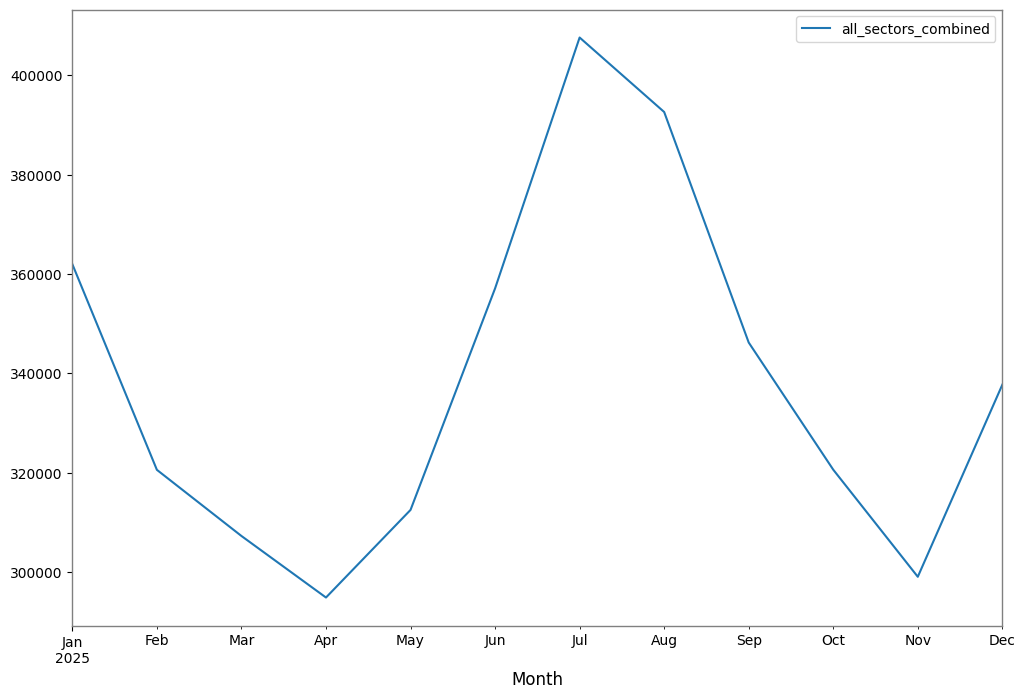

In [46]:
#let's plot the time series to see any trend
df_series.plot(figsize=(12,8))
plt.show()

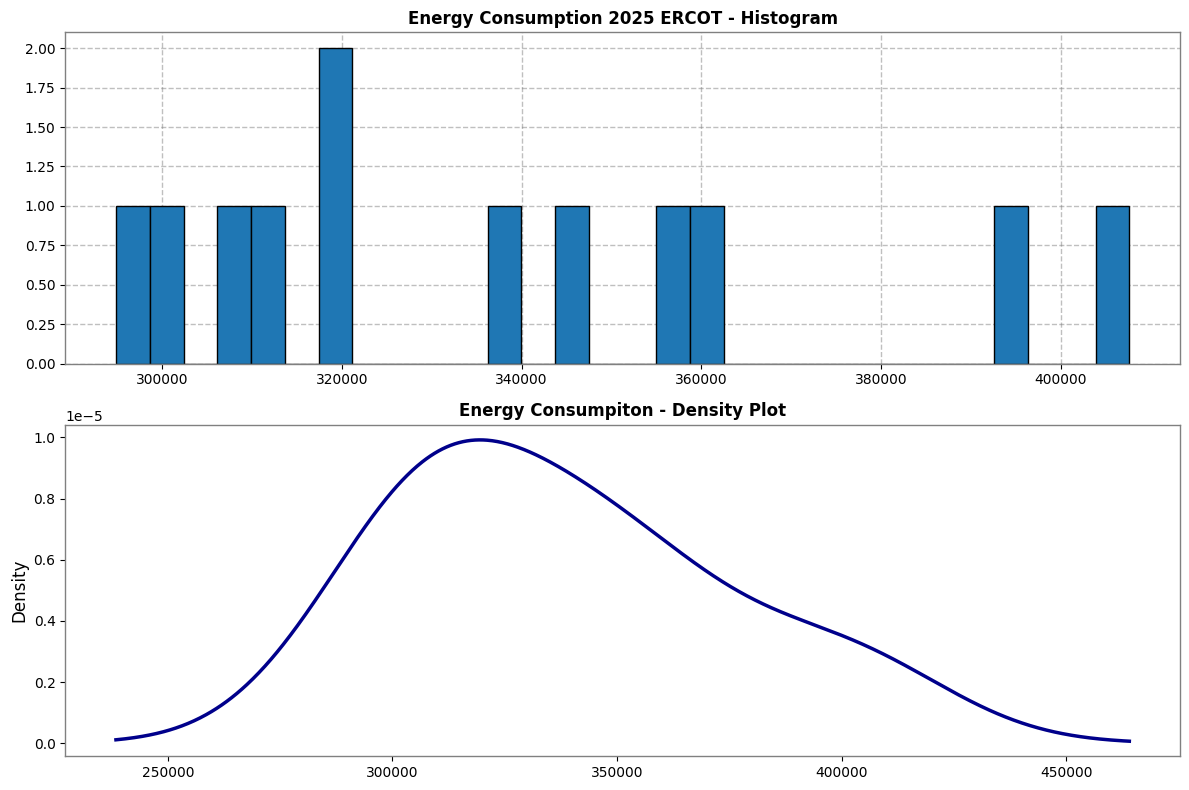

In [54]:
#plotting density analysis for energy consumption
plt.figure(figsize=(12,8))
#histogram to visualize frequency distribution
plt.subplot(2,1,1)
df_series['all_sectors_combined'].hist(bins=30, edgecolor='black')
plt.title('Energy Consumption 2025 ERCOT - Histogram')

#KDE plot to analyze distribution shape
plt.subplot(2,1,2)
df_series['all_sectors_combined'].plot(kind='kde', linewidth=2.5, color='darkblue')
plt.title('Energy Consumpiton - Density Plot')
plt.tight_layout()
plt.show()

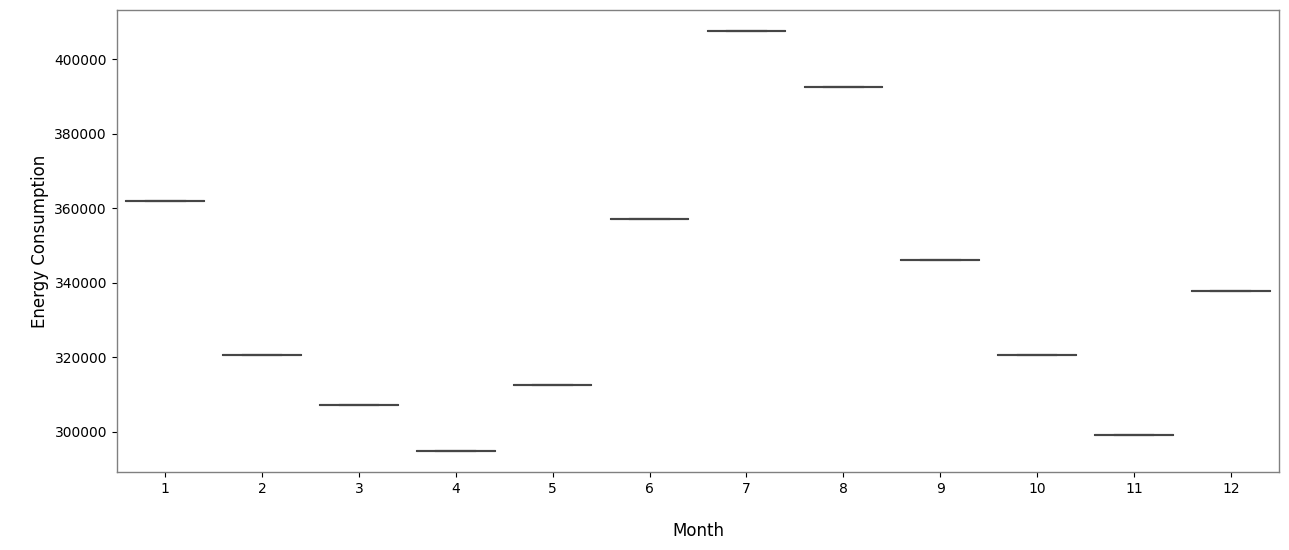

In [60]:
#month_index : month extracted from the index
#energy_values: time series values
#plotting area for the boxplots
fig, ax = plt.subplots(figsize=(15,6))
#extract month from index and define target variable
month_index = df_series.index.month
energy_values = df_series['all_sectors_combined']

#create a box plot for each month using seaborn
sns.boxplot(x=month_index, y=energy_values, ax=ax)
plt.xlabel("\nMonth")
plt.ylabel("\nEnergy Consumption")
plt.show()